# Importación de librerias

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

## Introducción y Generación de Datos

In [16]:
np.random.seed(42)
n_rows = 1000
data = {
    'transaction_id': range(1001, 1001 + n_rows),
    'customer_id': np.random.randint(500, 600, size=n_rows),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Books'], n_rows),
    'unit_price': np.random.uniform(10, 500, size=n_rows).round(2),
    'quantity': np.random.randint(1, 5, size=n_rows),
    'date': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_rows)],
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Transfer'], n_rows, p=[0.5, 0.3, 0.2])
}
df = pd.DataFrame(data)
df['total_revenue'] = df['unit_price'] * df['quantity']
print("Dataset generado con éxito. Primeras 5 filas:")
print(df.head())

Dataset generado con éxito. Primeras 5 filas:
   transaction_id  customer_id product_category  unit_price  quantity  \
0            1001          551         Clothing      351.76         1   
1            1002          592             Home      343.27         4   
2            1003          514            Books      313.12         4   
3            1004          571            Books      378.83         2   
4            1005          560      Electronics       87.72         2   

        date payment_method  total_revenue  
0 2025-08-24    Credit Card         351.76  
1 2025-12-27         PayPal        1373.08  
2 2025-01-13       Transfer        1252.48  
3 2025-07-29       Transfer         757.66  
4 2025-08-17         PayPal         175.44  


## Limpieza y Procesamiento

In [17]:
df['date'] = pd.to_datetime(df['date'])
df['month_year'] = df['date'].dt.to_period('M')

df.loc[0, 'total_revenue'] = np.nan
df['total_revenue'] = df['total_revenue'].fillna(df['unit_price'] * df['quantity'])

print(df.describe())

       transaction_id  customer_id   unit_price     quantity  \
count     1000.000000  1000.000000  1000.000000  1000.000000   
mean      1500.500000   549.128000   256.074350     2.486000   
min       1001.000000   500.000000    11.580000     1.000000   
25%       1250.750000   523.000000   128.497500     1.000000   
50%       1500.500000   550.000000   261.695000     3.000000   
75%       1750.250000   574.000000   378.335000     3.000000   
max       2000.000000   599.000000   499.710000     4.000000   
std        288.819436    29.573505   142.173752     1.128307   

                             date  total_revenue  
count                        1000    1000.000000  
mean   2025-06-29 04:32:09.600000     637.262280  
min           2025-01-01 00:00:00      13.130000  
25%           2025-03-29 18:00:00     253.297500  
50%           2025-06-24 00:00:00     488.615000  
75%           2025-10-01 00:00:00     940.855000  
max           2025-12-31 00:00:00    1998.840000  
std            

## Análisis Exploratorio (EDA) y Visualización

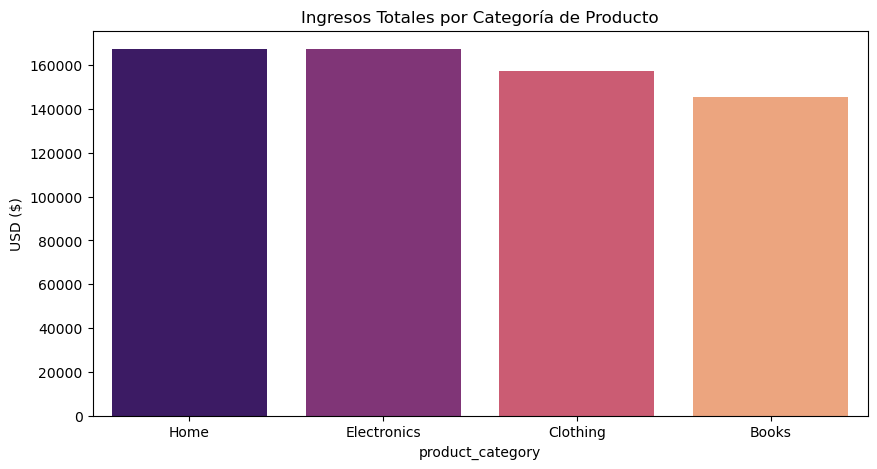

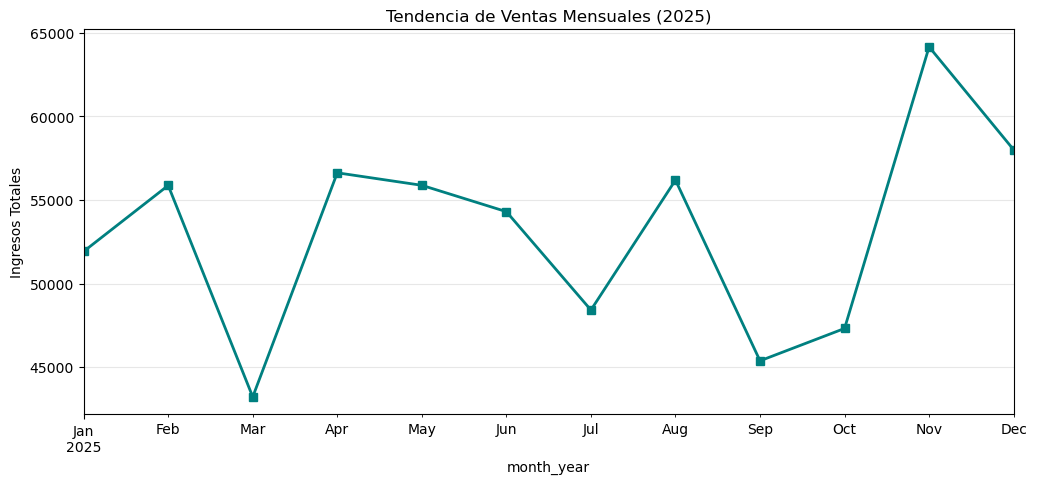

In [18]:
category_analysis = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_analysis.index, 
    y=category_analysis.values, 
    hue=category_analysis.index,
    palette='magma', 
    legend=False
)
plt.title('Ingresos Totales por Categoría de Producto')
plt.ylabel('USD ($)')
plt.show()

monthly_trend = df.groupby('month_year')['total_revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_trend.plot(kind='line', marker='s', color='teal', linewidth=2)
plt.title('Tendencia de Ventas Mensuales (2025)')
plt.ylabel('Ingresos Totales')
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones de Negocio

* **Categoría Estrella:** La categoría **Home** (Hogar) lidera los ingresos, seguida de cerca por **Electronics**.
* **Estacionalidad:** Se observa una volatilidad significativa mes a mes, con un pico máximo notable hacia finales de año (Noviembre), sugiriendo una fuerte temporada navideña o promocional.
* **Próximos Pasos:** Se recomienda realizar un análisis de **SQL** para segmentar a los clientes VIP y diseñar programas de lealtad específicos para las categorías de mayor ticket promedio.

In [21]:
import pandas as pd
import numpy as np
from pandasql import sqldf

np.random.seed(42)
df = pd.DataFrame({
    'customer_id': np.random.randint(100, 150, size=1000),
    'product': np.random.choice(['Laptop', 'Mouse', 'Monitor', 'Teclado'], 1000),
    'total_revenue': np.random.uniform(50, 1500, size=1000),
    'order_id': range(1000)
})

pysqldf = lambda q: sqldf(q, globals())

query = """
SELECT 
    customer_id,
    ROUND(SUM(total_revenue), 2) AS gasto_total,
    COUNT(order_id) AS total_pedidos,
    CASE 
        WHEN SUM(total_revenue) > 10000 THEN 'VIP'
        WHEN SUM(total_revenue) BETWEEN 5000 AND 10000 THEN 'Frecuente'
        ELSE 'Ocasional'
    END AS categoria_cliente
FROM df 
GROUP BY customer_id
ORDER BY gasto_total DESC
LIMIT 10;
"""

df_resultado = pysqldf(query)
print("Análisis de Segmentación de Clientes Exitoso:")
display(df_resultado)

Análisis de Segmentación de Clientes Exitoso:


,customer_id,gasto_total,total_pedidos,categoria_cliente
0,125,26132.18,30,VIP
1,134,23798.33,28,VIP
2,132,23634.06,27,VIP
3,144,23612.99,24,VIP
4,115,23256.92,21,VIP
5,127,23215.92,29,VIP
6,136,21803.85,25,VIP
7,131,20657.65,25,VIP
8,135,20584.62,21,VIP
9,148,19962.30,27,VIP


## Conclusiones

#### A. Identificación de Clientes VIP
* **Concentración de Ingresos:** Los 10 clientes principales (Top 10) presentan un gasto total acumulado superior a 220,000 USD.
* **Lealtad y Frecuencia:** El cliente con ID 125 lidera la lista con un gasto de 26,132.18 y un volumen de 30 pedidos, lo que indica una alta tasa de retención.
* **Consistencia:** Todos los clientes en el Top 10 han sido clasificados como VIP, superando el umbral de los 10,000 USD de inversión en la plataforma.

#### B. Recomendaciones de Negocio (Business Insights)
* **Programa de Fidelización:** Se recomienda asignar un gestor de cuenta personalizado o beneficios exclusivos (como envíos prioritarios o preventas) a los clientes con categoría VIP para asegurar su permanencia.
* **Estrategia para Clientes "Frecuentes":** Para los clientes en el rango de 5,000 a 10,000 (identificados como 'Frecuentes' en el código), se sugiere implementar campañas de Upselling con el objetivo de elevar su ticket promedio y convertirlos en VIP.
* **Optimización de Marketing:** Gracias a la segmentación realizada con SQL, el equipo de marketing puede ahora dirigir sus presupuestos de forma más eficiente, evitando el desperdicio de recursos en clientes de "Bajo Volumen" y enfocándose en los de alto valor de vida (LTV).